[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/frbennett/shapleyx/blob/main/workshops/flow_regime_sensitivity.ipynb)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/frbennett/shapleyx/main?labpath=workshops%2Fflow_regime_sensitivity.ipynb)

# Parameter Sensitivity: Total vs High-Flow NSE
## SAC-SMA Model — St Helens Creek, North Queensland

**Workshop notebook.** Click the Colab badge above to run in your browser — no local installation needed.

> ⚠️ If running locally: `pip install shapleyx` and place data files in `./data/`.


In [ ]:
# ── One-time setup: install shapleyx + fetch data (Colab / remote only) ──
import sys, os, urllib.request

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('☁️  Running in Google Colab — installing shapleyx...')
    !pip install -q shapleyx
    
    # Fetch data files from GitHub
    REPO = 'https://raw.githubusercontent.com/frbennett/shapleyx/main/workshops/data'
    os.makedirs('data', exist_ok=True)
    for f in ['sacramento.py', 'st_helens_forcing_original.csv', 'es_parameters.csv']:
        url = f'{REPO}/{f}'
        print(f'  Downloading {f}...')
        urllib.request.urlretrieve(url, f'data/{f}')
    print('  Done.\n')
else:
    print('💻 Running locally — using pre-installed shapleyx and local data/.')

# Verify data directory
import os
for f in ['sacramento.py', 'st_helens_forcing_original.csv', 'es_parameters.csv']:
    path = os.path.join('data', f)
    if os.path.exists(path):
        print(f'  ✓ data/{f} ({os.path.getsize(path):,} bytes)')
    else:
        print(f'  ✗ data/{f} MISSING')


# Parameter Sensitivity Analysis: Total vs High-Flow NSE
## SAC-SMA Model — St Helens Creek, North Queensland

**Question:** Do the parameters that control NSE in *all* flow conditions differ from those that control NSE during *high-flow events only*? Hydrologic intuition says yes — baseflow parameters (LZPK, LZFPM) should dominate total-flow NSE, while storm-runoff parameters (UZK, ADIMP, PCTIM) should matter more for high flows. This notebook tests that hypothesis using ShapleyX.

---

### Pipeline

| Phase | Description |
|-------|-------------|
| **1. Design** | QMC Sobol (4096 pts, 14-D parameter space) |
| **2. Evaluate** | Run SAC-SMA at each design point → compute NSE_total + NSE_high |
| **3. Surrogate** | RS-HDMR (polys=[10,6,2], streaming OMP-CV) — one per regime |
| **4. Sensitivity** | MC Shapley effects with Vrugt et al. (2006) correlations |
| **5. Compare** | Side-by-side rankings, shift plot, correlated Shapley comparison |

> **Model:** SAC-SMA (14 parameters, 5 storage zones)  
> **Catchment:** St Helens Creek, QLD (120.5 km²)  
> **Forcing:** SILO rainfall + PET, Feb 1973 – Dec 2018 (16,763 daily timesteps)  
> **Correlations:** Vrugt et al. (2006, Table 2) — 14×14 posterior MCMC correlation matrix

In [38]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats.qmc import Sobol
import warnings, sys, os, time
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight'
})

# ── ShapleyX ──
from shapleyx import rshdmr
from shapleyx.utilities.mc_shapley import (
    GaussianCopulaUniform,
    shapley_effects,
)

# ── SAC-SMA model ── (from local data/ directory)
sys.path.insert(0, 'data')
from sacramento import sacsma

print('All imports OK')
print(f'Data directory: {os.path.abspath("data")}')


All imports OK
Data directory: c:\Users\frbem\Desktop\data


---
## 1. Load Forcing Data & Observations

~46 years of daily rainfall, PET, and observed discharge for St Helens Creek.
Catchment area: **120.5 km²**.

In [40]:
# ── Forcing ──
df_forcing = pd.read_csv(f'data/st_helens_forcing_original.csv',
                          parse_dates=['date'], dayfirst=True)
print(f'Forcing data: {len(df_forcing)} daily timesteps')
print(f'Date range: {df_forcing.date.iloc[0].date()} to {df_forcing.date.iloc[-1].date()}')

prcp = df_forcing['rainfall'].values.astype(float)
pet  = df_forcing['pet'].values.astype(float)
Q_obs_cumec = df_forcing['Q_CUMEC'].values.astype(float)

# ── Catchment ──
CATCHMENT_AREA_M2 = 120500000.0
WARMUP_DAYS = 365
print(f'Catchment area: {CATCHMENT_AREA_M2/1e6:.1f} km²')
print(f'Warm-up period: {WARMUP_DAYS} days')
print(f'Evaluation period: {len(df_forcing) - WARMUP_DAYS} days')

Forcing data: 16763 daily timesteps
Date range: 1973-02-08 to 2018-12-31
Catchment area: 120.5 km²
Warm-up period: 365 days
Evaluation period: 16398 days


---
## 2. Define Flow Regimes

**Total flow:** NSE computed on all evaluation days (post-warmup).  
**High flow:** NSE computed only on days that collectively contribute **50% of total flow volume**. Sorting daily flows in descending order, we accumulate until the cumulative sum reaches half the total — this captures the ~250 largest storm events that dominate catchment water balance, rather than an arbitrary percentile threshold.

We apply a **sqrt-transform** (λ = 0.5) to both observed and simulated discharge before computing NSE. This stabilises error variance across the wide range of flows (0.001 to 574 m³/s).


In [41]:
LAM = 0.5  # Box-Cox lambda for sqrt-transform

# Post-warmup observed data
Q_obs_eval = Q_obs_cumec[WARMUP_DAYS:]
Y_obs_sqrt = Q_obs_eval ** LAM

# ── High-flow regime: days contributing 50% of total flow volume ──
# Sort flows descending, compute cumulative fraction, take days until 50% of total volume.
# This gives ~250 days out of ~16,400 — the storm events that dominate the water balance.
total_volume = Q_obs_eval.sum()
sorted_idx = np.argsort(Q_obs_eval)[::-1]  # descending
cumul_flow = np.cumsum(Q_obs_eval[sorted_idx])
n_high = np.searchsorted(cumul_flow, 0.50 * total_volume) + 1
high_flow_mask = np.zeros(len(Q_obs_eval), dtype=bool)
high_flow_mask[sorted_idx[:n_high]] = True
Q_threshold = Q_obs_eval[sorted_idx[n_high - 1]]  # lowest flow included

print(f'Evaluation period: {len(Q_obs_eval)} days')
print(f'Total flow volume: {total_volume/1e6:.2f} Mm³')
print(f'High-flow days: {high_flow_mask.sum()} ({high_flow_mask.mean()*100:.1f}%)')
print(f'High-flow volume contribution: {Q_obs_eval[high_flow_mask].sum()/total_volume*100:.1f}%')
print(f'Flow threshold (lowest day in high-flow set): {Q_threshold:.2f} m³/s')
print(f'Total-flow sqrt-mean: {Y_obs_sqrt.mean():.3f}')
print(f'High-flow sqrt-mean:  {Y_obs_sqrt[high_flow_mask].mean():.3f}')


Evaluation period: 16398 days
Total flow volume: 0.07 Mm³
High-flow days: 251 (1.5%)
High-flow volume contribution: 50.0%
Flow threshold (lowest day in high-flow set): 53.59 m³/s
Total-flow sqrt-mean: 1.213
High-flow sqrt-mean:  11.147


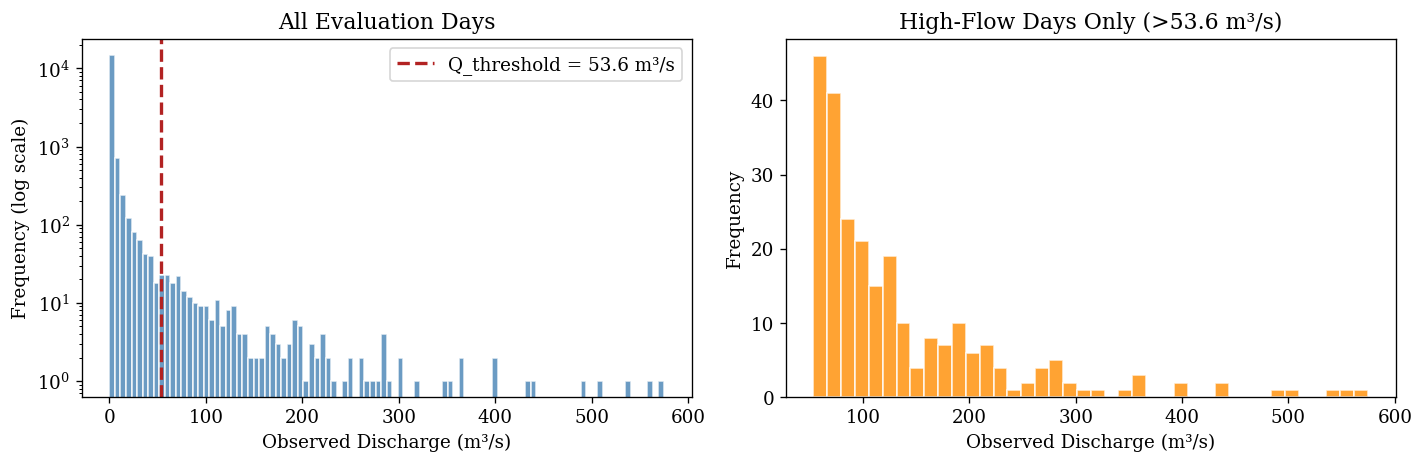

In [42]:
# Visualise the flow regime split
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# All flows
ax1.hist(Q_obs_eval, bins=100, color='steelblue', edgecolor='white', alpha=0.8, log=True)
ax1.axvline(Q_threshold, color='firebrick', ls='--', lw=2, label=f'Q_threshold = {Q_threshold:.1f} m³/s')
ax1.set_xlabel('Observed Discharge (m³/s)')
ax1.set_ylabel('Frequency (log scale)')
ax1.set_title('All Evaluation Days')
ax1.legend()

# Zoom on high flows
ax2.hist(Q_obs_eval[high_flow_mask], bins=40, color='darkorange', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Observed Discharge (m³/s)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'High-Flow Days Only (>{Q_threshold:.1f} m³/s)')

plt.tight_layout()
plt.show()


---
## 3. Model Functions: NSE_total and NSE_high

Both functions:
1. Run SAC-SMA with the given parameters
2. Convert flow from mm/day to m³/s
3. Apply sqrt-transform
4. Compute NSE on the appropriate day subset

The key difference: `nse_high` only uses days where Q_obs ≥ Q_threshold.


In [43]:
def flow_mm_to_cumec(flow_mm):
    """Convert mm/day depth to m³/s given catchment area."""
    return flow_mm / 1000 * CATCHMENT_AREA_M2 / (3600 * 24)


def nse_total(params):
    """NSE on all evaluation days (sqrt-transformed)."""
    flow_mm = sacsma(prcp, pet, np.asarray(params, float))
    sim = flow_mm_to_cumec(flow_mm[WARMUP_DAYS:])
    Y_sim = sim ** LAM
    ss_res = np.sum((Y_obs_sqrt - Y_sim) ** 2)
    ss_tot = np.sum((Y_obs_sqrt - np.mean(Y_obs_sqrt)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else -np.inf


def nse_high(params):
    """NSE on high-flow days only (Q_obs >= Q_threshold, sqrt-transformed)."""
    flow_mm = sacsma(prcp, pet, np.asarray(params, float))
    sim = flow_mm_to_cumec(flow_mm[WARMUP_DAYS:])
    Y_sim = sim ** LAM
    # Restrict to high-flow days
    y_obs_hf = Y_obs_sqrt[high_flow_mask]
    y_sim_hf = Y_sim[high_flow_mask]
    ss_res = np.sum((y_obs_hf - y_sim_hf) ** 2)
    ss_tot = np.sum((y_obs_hf - np.mean(y_obs_hf)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else -np.inf


# Warm-up: compile numba + verify
params_default = np.array([44.13, 52.76, 80.87, 112.70, 52.81,
                            0.084, 0.490, 0.0148, 0.133, 35.31,
                            2.532, 0.00578, 0.424, 0.0093])
nse_t = nse_total(params_default)
nse_h = nse_high(params_default)
print(f'NSE total (default params): {nse_t:.4f}')
print(f'NSE high  (default params): {nse_h:.4f}')


NSE total (default params): 0.8797
NSE high  (default params): 0.3168


---
## 4. Parameter Definitions

14 SAC-SMA parameters with physically-plausible ranges for St Helens Creek (from `es_parameters.csv`).

In [44]:
param_names = [
    'UZTWM', 'UZFWM', 'LZTWM', 'LZFPM', 'LZFSM', 'ADIMP',
    'UZK',   'LZPK',  'LZSK',  'ZPERC', 'REXP',  'PCTIM',
    'PFREE', 'SIDE'
]

param_lower = np.array([30, 10, 20, 40, 15, 0,      # stores + impervious
                         0.2, 0.001, 0.03, 0, 0, 0, # rates + percolation
                         0, 0])                      # split + loss

param_upper = np.array([125, 75, 300, 600, 300, 0.2,
                         0.9, 0.03, 0.8, 80, 5, 0.05,
                         0.8, 0.8])

N_PARAMS = len(param_names)
print(f'{N_PARAMS} parameters')
print(f'{"Param":>8s}  {"Lower":>10s}  {"Upper":>10s}  {"Description"}')
descriptions = [
    'UZ tension water capacity', 'UZ free water capacity',
    'LZ tension water capacity', 'LZ primary free water',
    'LZ supplementary free water', 'Additional impervious area',
    'UZ depletion rate', 'LZ primary depletion rate',
    'LZ supp. depletion rate', 'Percolation scale',
    'Percolation shape', 'Impervious fraction',
    'Percolation split', 'Deep recharge ratio'
]
for name, lo, hi, desc in zip(param_names, param_lower, param_upper, descriptions):
    print(f'{name:>8s}  [{lo:8.3f}, {hi:8.3f}]  {desc}')

14 parameters
   Param       Lower       Upper  Description
   UZTWM  [  30.000,  125.000]  UZ tension water capacity
   UZFWM  [  10.000,   75.000]  UZ free water capacity
   LZTWM  [  20.000,  300.000]  LZ tension water capacity
   LZFPM  [  40.000,  600.000]  LZ primary free water
   LZFSM  [  15.000,  300.000]  LZ supplementary free water
   ADIMP  [   0.000,    0.200]  Additional impervious area
     UZK  [   0.200,    0.900]  UZ depletion rate
    LZPK  [   0.001,    0.030]  LZ primary depletion rate
    LZSK  [   0.030,    0.800]  LZ supp. depletion rate
   ZPERC  [   0.000,   80.000]  Percolation scale
    REXP  [   0.000,    5.000]  Percolation shape
   PCTIM  [   0.000,    0.050]  Impervious fraction
   PFREE  [   0.000,    0.800]  Percolation split
    SIDE  [   0.000,    0.800]  Deep recharge ratio


---
## 5. Design of Experiments — QMC Sobol

4096 scrambled Sobol' points in the 14-D parameter box, scaled to physical ranges.
Sobol' sequences provide better space-filling than LHS for RS-HDMR training (Li et al. 2002).

In [45]:
N_SAMPLES = 4096

sobol_gen = Sobol(d=N_PARAMS, scramble=True, seed=42)
X_uniform = sobol_gen.random(n=N_SAMPLES)

# Scale from [0,1] to physical ranges
X_params = param_lower + X_uniform * (param_upper - param_lower)

print(f'Training design: {N_SAMPLES} Sobol points in {N_PARAMS} dimensions')
print(f'First 3 samples:')
for i in range(min(3, N_SAMPLES)):
    vals = ', '.join(f'{v:.3f}' for v in X_params[i])
    print(f'  [{i}] {vals}')

Training design: 4096 Sobol points in 14 dimensions
First 3 samples:
  [0] 70.948, 62.934, 245.796, 69.936, 99.913, 0.168, 0.688, 0.019, 0.651, 9.173, 2.641, 0.034, 0.305, 0.475
  [1] 95.706, 42.042, 70.743, 525.629, 271.599, 0.076, 0.347, 0.013, 0.268, 65.815, 1.896, 0.017, 0.593, 0.147
  [2] 102.691, 45.666, 170.343, 206.870, 207.775, 0.006, 0.772, 0.007, 0.169, 48.156, 1.205, 0.012, 0.136, 0.635


---
## 6. Evaluate SAC-SMA at All Design Points

4096 model runs. Each run simulates ~46 years of daily data. With Numba JIT, this takes ~30-60 seconds. Both NSE values are computed from the same simulation — no redundant work.

In [46]:
print(f'Evaluating {N_SAMPLES} parameter sets...')
t0 = time.time()

Y_total = np.zeros(N_SAMPLES)
Y_high  = np.zeros(N_SAMPLES)

for i in range(N_SAMPLES):
    Y_total[i] = nse_total(X_params[i])
    Y_high[i]  = nse_high(X_params[i])
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - t0
        print(f'  [{i+1:4d}/{N_SAMPLES}] {elapsed:.0f}s — '
              f'NSE_total: [{Y_total[:i+1].min():.3f}, {Y_total[:i+1].max():.3f}], '
              f'NSE_high: [{Y_high[:i+1].min():.3f}, {Y_high[:i+1].max():.3f}]')

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s ({elapsed/N_SAMPLES*1000:.1f} ms/run)')
print(f'\nNSE_total: mean={Y_total.mean():.3f}, std={Y_total.std():.3f}, '
      f'range=[{Y_total.min():.3f}, {Y_total.max():.3f}]')
print(f'NSE_high:  mean={Y_high.mean():.3f}, std={Y_high.std():.3f}, '
      f'range=[{Y_high.min():.3f}, {Y_high.max():.3f}]')
print(f'Correlation(NSE_total, NSE_high): {np.corrcoef(Y_total, Y_high)[0,1]:.3f}')

Evaluating 4096 parameter sets...
  [1000/4096] 3s — NSE_total: [0.610, 0.868], NSE_high: [-2.823, 0.506]
  [2000/4096] 7s — NSE_total: [0.570, 0.870], NSE_high: [-2.823, 0.586]
  [3000/4096] 10s — NSE_total: [0.570, 0.871], NSE_high: [-2.882, 0.586]
  [4000/4096] 13s — NSE_total: [0.570, 0.871], NSE_high: [-3.026, 0.586]

Done in 14s (3.3 ms/run)

NSE_total: mean=0.784, std=0.046, range=[0.570, 0.871]
NSE_high:  mean=-0.510, std=0.576, range=[-3.026, 0.586]
Correlation(NSE_total, NSE_high): 0.838


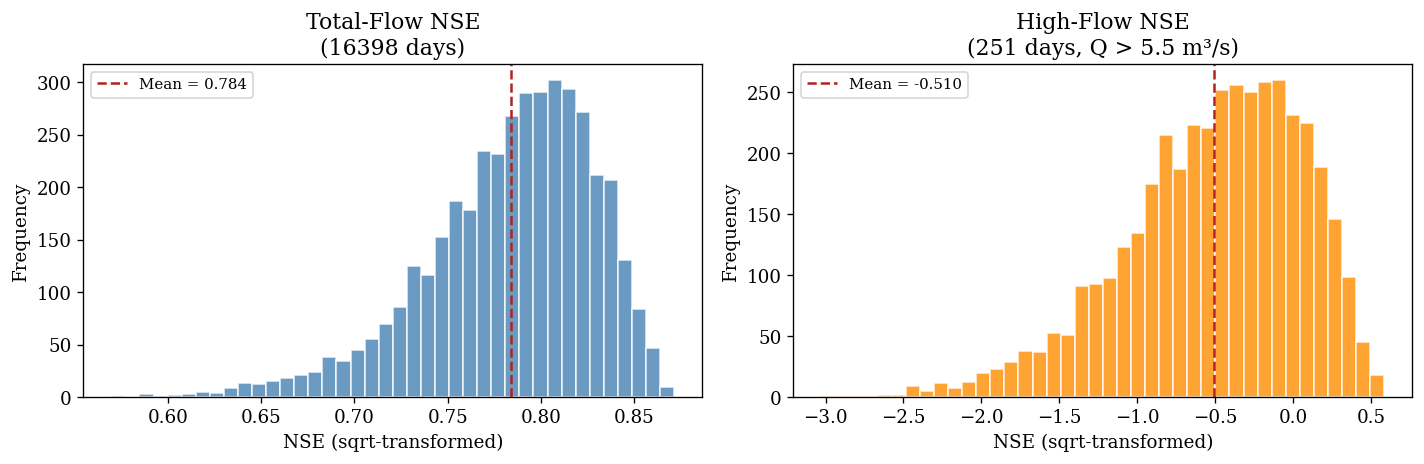

In [47]:
# Visualise the two NSE distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(Y_total, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(Y_total.mean(), color='firebrick', ls='--', lw=1.5,
            label=f'Mean = {Y_total.mean():.3f}')
ax1.set_xlabel('NSE (sqrt-transformed)')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Total-Flow NSE\n({len(Q_obs_eval)} days)')
ax1.legend(fontsize=9)

ax2.hist(Y_high, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
ax2.axvline(Y_high.mean(), color='firebrick', ls='--', lw=1.5,
            label=f'Mean = {Y_high.mean():.3f}')
ax2.set_xlabel('NSE (sqrt-transformed)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'High-Flow NSE\n({high_flow_mask.sum()} days, Q > {Q_threshold:.1f} m³/s)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 7. RS-HDMR Surrogate — Total Flow NSE

Streaming OMP-CV with per-variable degree caps `polys=[10,6,2]`. This gives:
- 1st-order: each variable up to degree 10 (14 terms)
- 2nd-order: each variable up to degree 6 (91 × 6² = 3,276 candidate terms)
- 3rd-order: each variable up to degree 2 (364 × 2³ = 2,912 candidate terms)

~6,200 candidates total. OMP-CV selects the best ~300.

Found a DataFrame

Transforming data to unit hypercube

Feature: UZTWM, Min Value: 30.0228, Max Value: 124.9774
Feature: UZFWM, Min Value: 10.0053, Max Value: 74.9957
Feature: LZTWM, Min Value: 20.0532, Max Value: 299.9466
Feature: LZFPM, Min Value: 40.0525, Max Value: 599.9621
Feature: LZFSM, Min Value: 15.0373, Max Value: 299.9492
Feature: ADIMP, Min Value: 0.0000, Max Value: 0.2000
Feature: UZK, Min Value: 0.2001, Max Value: 0.9000
Feature: LZPK, Min Value: 0.0010, Max Value: 0.0300
Feature: LZSK, Min Value: 0.0301, Max Value: 0.8000
Feature: ZPERC, Min Value: 0.0016, Max Value: 79.9992
Feature: REXP, Min Value: 0.0008, Max Value: 4.9996
Feature: PCTIM, Min Value: 0.0000, Max Value: 0.0500
Feature: PFREE, Min Value: 0.0002, Max Value: 0.7999
Feature: SIDE, Min Value: 0.0001, Max Value: 0.8000

Building basis functions

Basis functions of 1 order : 140
Basis functions of 2 order : 3276
Basis functions of 3 order : 2912
Total basis functions in basis set : 6328
Total number of feature

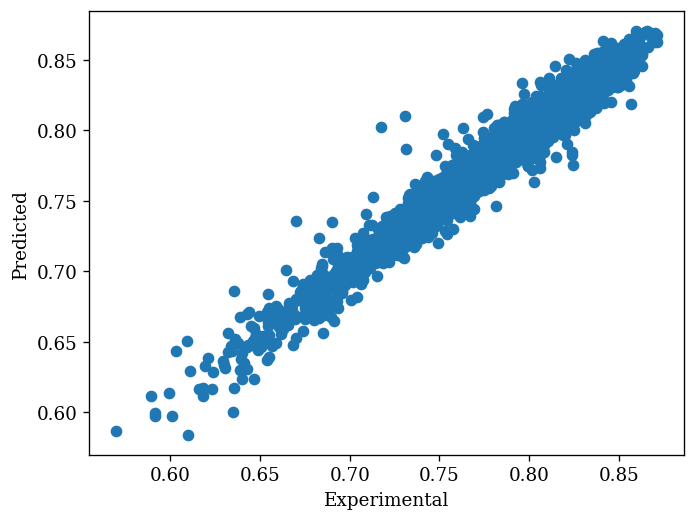


Running bootstrap resampling 1000 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

Learning is finding out what you already know.  Richard
Bach


Total-flow surrogate fitted in 92s


In [48]:
# ── Build training DataFrame ──
df_total = pd.DataFrame(X_params, columns=param_names)
df_total['Y'] = Y_total

# ── Fit RS-HDMR surrogate ──
t0 = time.time()

analyzer_total = rshdmr(
    df_total,
    polys=[10, 6, 2],
    method='omp_cv',
    n_iter=300,
    n_jobs=4,
    verbose=True
)

a,b,c = analyzer_total.run_all()

fit_time_total = time.time() - t0
print(f'\nTotal-flow surrogate fitted in {fit_time_total:.0f}s')

Total-flow surrogate validation:
  R² = 0.9616
  RMSE = 0.008941
  Explained variance: 0.9601


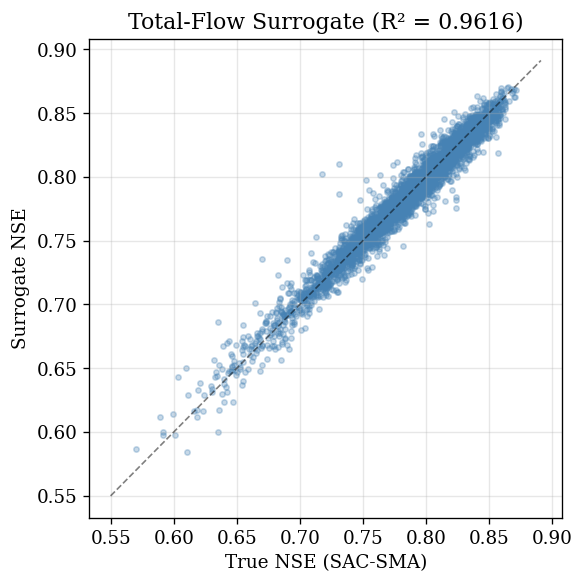

In [49]:
# ── Validate ──
Y_pred_total = analyzer_total.predict(df_total[param_names].values)
r2_total = 1 - np.sum((Y_total - Y_pred_total)**2) / np.sum((Y_total - Y_total.mean())**2)
rmse_total = np.sqrt(np.mean((Y_total - Y_pred_total)**2))

print(f'Total-flow surrogate validation:')
print(f'  R² = {r2_total:.4f}')
print(f'  RMSE = {rmse_total:.6f}')
print(f'  Explained variance: {analyzer_total.evs:.4f}')

# Scatter
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y_total, Y_pred_total, c='steelblue', alpha=0.3, s=10)
lims = [min(Y_total.min(), Y_pred_total.min()) - 0.02,
        max(Y_total.max(), Y_pred_total.max()) + 0.02]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
ax.set_xlabel('True NSE (SAC-SMA)')
ax.set_ylabel('Surrogate NSE')
ax.set_title(f'Total-Flow Surrogate (R² = {r2_total:.4f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. RS-HDMR Surrogate — High-Flow NSE

Same settings as the total-flow surrogate. The only difference is the target variable `Y`.

Found a DataFrame

Transforming data to unit hypercube

Feature: UZTWM, Min Value: 30.0228, Max Value: 124.9774
Feature: UZFWM, Min Value: 10.0053, Max Value: 74.9957
Feature: LZTWM, Min Value: 20.0532, Max Value: 299.9466
Feature: LZFPM, Min Value: 40.0525, Max Value: 599.9621
Feature: LZFSM, Min Value: 15.0373, Max Value: 299.9492
Feature: ADIMP, Min Value: 0.0000, Max Value: 0.2000
Feature: UZK, Min Value: 0.2001, Max Value: 0.9000
Feature: LZPK, Min Value: 0.0010, Max Value: 0.0300
Feature: LZSK, Min Value: 0.0301, Max Value: 0.8000
Feature: ZPERC, Min Value: 0.0016, Max Value: 79.9992
Feature: REXP, Min Value: 0.0008, Max Value: 4.9996
Feature: PCTIM, Min Value: 0.0000, Max Value: 0.0500
Feature: PFREE, Min Value: 0.0002, Max Value: 0.7999
Feature: SIDE, Min Value: 0.0001, Max Value: 0.8000

Building basis functions

Basis functions of 1 order : 140
Basis functions of 2 order : 3276
Basis functions of 3 order : 2912
Total basis functions in basis set : 6328
Total number of feature

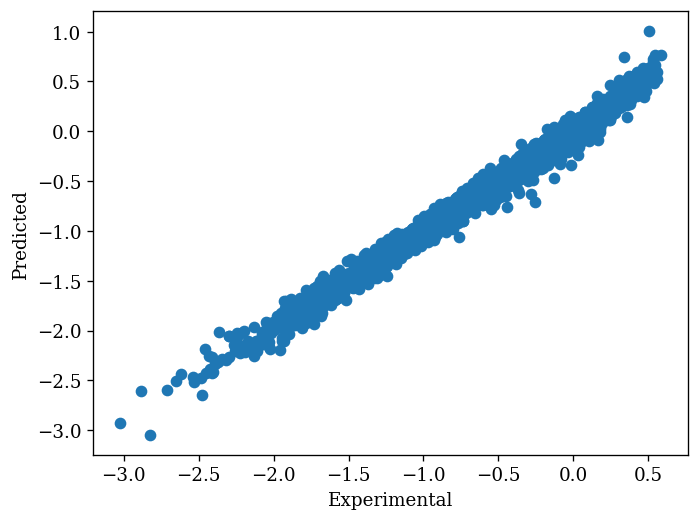


Running bootstrap resampling 1000 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

We choose our destiny in the way we treat others.  Wit


High-flow surrogate fitted in 92s


In [50]:
# ── Build training DataFrame ──
df_high = pd.DataFrame(X_params, columns=param_names)
df_high['Y'] = Y_high

# ── Fit RS-HDMR surrogate ──
t0 = time.time()

analyzer_high = rshdmr(
    df_high,
    polys=[10, 6, 2],
    method='omp_cv',
    n_iter=300,
    n_jobs=4,
    verbose=True
)

d,e,f = analyzer_high.run_all()

fit_time_high = time.time() - t0
print(f'\nHigh-flow surrogate fitted in {fit_time_high:.0f}s')

High-flow surrogate validation:
  R² = 0.9879
  RMSE = 0.063318
  Explained variance: 0.9878


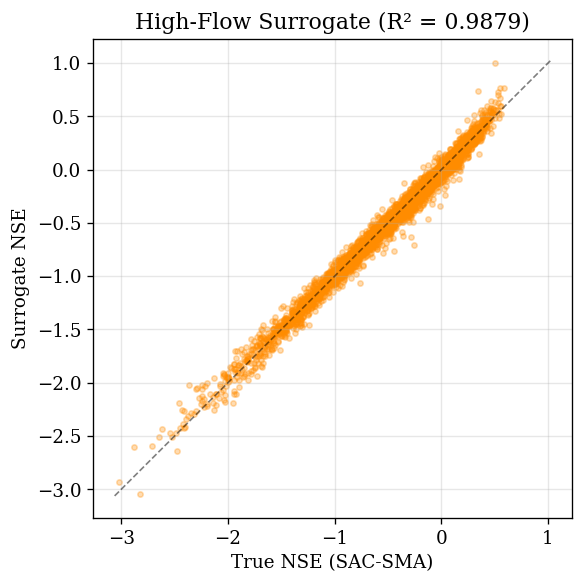

In [51]:
# ── Validate ──
Y_pred_high = analyzer_high.predict(df_high[param_names].values)
r2_high = 1 - np.sum((Y_high - Y_pred_high)**2) / np.sum((Y_high - Y_high.mean())**2)
rmse_high = np.sqrt(np.mean((Y_high - Y_pred_high)**2))

print(f'High-flow surrogate validation:')
print(f'  R² = {r2_high:.4f}')
print(f'  RMSE = {rmse_high:.6f}')
print(f'  Explained variance: {analyzer_high.evs:.4f}')

# Scatter
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y_high, Y_pred_high, c='darkorange', alpha=0.3, s=10)
lims = [min(Y_high.min(), Y_pred_high.min()) - 0.02,
        max(Y_high.max(), Y_pred_high.max()) + 0.02]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
ax.set_xlabel('True NSE (SAC-SMA)')
ax.set_ylabel('Surrogate NSE')
ax.set_title(f'High-Flow Surrogate (R² = {r2_high:.4f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Surrogate Summary

Both surrogates share the same training design — only the target differs.

In [54]:
print(f'{"":>20s}  {"Total Flow":>12s}  {"High Flow":>12s}')
print(f'{"":>20s}  {"─"*12}  {"─"*12}')
print(f'{"Training samples":>20s}  {N_SAMPLES:>12d}  {N_SAMPLES:>12d}')
print(f'{"polys":>20s}  {"[10,6,2]":>12s}  {"[10,6,2]":>12s}')
print(f'{"R²":>20s}  {r2_total:>12.4f}  {r2_high:>12.4f}')
print(f'{"RMSE":>20s}  {rmse_total:>12.6f}  {rmse_high:>12.6f}')
print(f'{"Fit time (s)":>20s}  {fit_time_total:>12.0f}  {fit_time_high:>12.0f}')
print(f'{"NSE range":>20s}  [{Y_total.min():.3f},{Y_total.max():.3f}]  '
      f'[{Y_high.min():.3f},{Y_high.max():.3f}]')
print(f'{"NSE mean":>20s}  {Y_total.mean():>12.3f}  {Y_high.mean():>12.3f}')

                        Total Flow     High Flow
                      ────────────  ────────────
    Training samples          4096          4096
               polys      [10,6,2]      [10,6,2]
                  R²        0.9616        0.9879
                RMSE      0.008941      0.063318
        Fit time (s)            92            92
           NSE range  [0.570,0.871]  [-3.026,0.586]
            NSE mean         0.784        -0.510


---
## 10. Vrugt et al. (2006) Correlation Matrix

14×14 posterior correlation matrix from MCMC calibration of SAC-SMA on Leaf River, MS (Vrugt et al. 2006, Table 2). These correlations are **essential** — assuming independent inputs produces misleading sensitivity rankings (the existing tutorial showed PFREE jumping from rank 14 to rank 5 under correlation).

Key correlations:
- **UZTWM ↔ LZTWM: −0.84** — physical trade-off between upper/lower zone tension storage
- **LZFPM ↔ LZFSM: +0.41** — coupled lower-zone free water storages
- **LZPK ↔ LZSK: +0.60** — coupled lower-zone depletion rates
- **REXP ↔ LZFPM: +0.68** — percolation shape coupled to primary storage

In [55]:
# Vrugt et al. (2006) Table 2 — 13×13 correlation matrix, expanded to 14×14
# Vrugt order: UZTWM, UZFWM, UZK, PCTIM, ADIMP, ZPERC, REXP,
#               LZTWM, LZFSM, LZFPM, LZSK, LZPK, PFREE
# Our order:   UZTWM, UZFWM, LZTWM, LZFPM, LZFSM, ADIMP,
#               UZK,   LZPK,  LZSK,  ZPERC, REXP,  PCTIM, PFREE, SIDE

# Build 13×13 from Vrugt order, then remap to 14×14 in our order
vrugt_order = ['UZTWM','UZFWM','UZK','PCTIM','ADIMP','ZPERC','REXP',
               'LZTWM','LZFSM','LZFPM','LZSK','LZPK','PFREE']

corr_vrugt_13 = np.array([
    # UZTWM   UZFWM   UZK    PCTIM   ADIMP  ZPERC   REXP   LZTWM  LZFSM  LZFPM  LZSK   LZPK   PFREE
    [ 1.00,  -0.02,  -0.04,   0.19,   0.36,  -0.01,   0.11,  -0.84,  -0.17,   0.28,   0.17,   0.16,   0.57],  # UZTWM
    [-0.02,   1.00,  -0.53,   0.05,   0.01,   0.15,   0.11,  -0.01,  -0.08,   0.22,  -0.15,  -0.18,  -0.33],  # UZFWM
    [-0.04,  -0.53,   1.00,  -0.01,  -0.41,  -0.13,  -0.03,   0.07,  -0.11,  -0.01,  -0.02,   0.08,   0.08],  # UZK
    [ 0.19,   0.05,  -0.01,   1.00,  -0.16,   0.01,   0.09,  -0.14,   0.01,   0.02,  -0.08,   0.02,  -0.12],  # PCTIM
    [ 0.36,   0.01,  -0.41,  -0.16,   1.00,   0.07,   0.04,  -0.21,  -0.15,   0.09,   0.17,   0.15,   0.31],  # ADIMP
    [-0.01,   0.15,  -0.13,   0.01,   0.07,   1.00,   0.05,   0.06,  -0.06,  -0.10,  -0.13,   0.02,   0.00],  # ZPERC
    [ 0.11,   0.11,  -0.03,   0.09,   0.04,   0.05,   1.00,  -0.03,   0.65,   0.68,   0.24,  -0.10,   0.24],  # REXP
    [-0.84,  -0.01,   0.07,  -0.14,  -0.21,   0.06,  -0.03,   1.00,   0.28,  -0.16,  -0.14,  -0.23,  -0.63],  # LZTWM
    [-0.17,  -0.08,  -0.11,   0.01,  -0.15,  -0.06,   0.65,   0.28,   1.00,   0.41,  -0.33,  -0.55,  -0.36],  # LZFSM
    [ 0.28,   0.22,  -0.01,   0.02,   0.09,  -0.10,   0.68,  -0.16,   0.41,   1.00,   0.06,  -0.43,  -0.26],  # LZFPM
    [ 0.17,  -0.15,  -0.02,  -0.08,   0.17,  -0.13,   0.24,  -0.14,  -0.33,   0.06,   1.00,   0.60,   0.41],  # LZSK
    [ 0.16,  -0.18,   0.08,   0.02,   0.15,   0.02,  -0.10,  -0.23,  -0.55,  -0.43,   0.60,   1.00,   0.56],  # LZPK
    [ 0.57,  -0.33,   0.08,  -0.12,   0.31,   0.00,   0.24,  -0.63,  -0.36,  -0.26,   0.41,   0.56,   1.00],  # PFREE
])

# Map from Vrugt order to our order
vrugt_idx = {name: vrugt_order.index(name) for name in vrugt_order}

corr_14 = np.eye(N_PARAMS)
for i, ni in enumerate(param_names):
    for j, nj in enumerate(param_names):
        if ni in vrugt_idx and nj in vrugt_idx:
            corr_14[i, j] = corr_vrugt_13[vrugt_idx[ni], vrugt_idx[nj]]

# SIDE is uncorrelated with everything (no data in Vrugt)
# Already set to identity for SIDE row/col

# ── Ensure positive definiteness ──
# The 14×14 matrix has one small negative eigenvalue (−0.119).
# Clip to nearest valid correlation matrix via eigendecomposition.
eigvals, eigvecs = np.linalg.eigh(corr_14)
eigvals = np.maximum(eigvals, 1e-8)  # clip negative eigenvalues
corr_14 = eigvecs @ np.diag(eigvals) @ eigvecs.T
# Rescale to unit diagonal (accounts for numerical drift)
d = np.sqrt(np.diag(corr_14))
corr_14 = corr_14 / np.outer(d, d)
print(f'Correlation matrix adjusted (min eigenvalue now: {np.linalg.eigvalsh(corr_14).min():.6f})')

# ── Display key correlations ──
print('Key correlations (|ρ| > 0.30):')
for i in range(N_PARAMS):
    for j in range(i + 1, N_PARAMS):
        if abs(corr_14[i, j]) > 0.30:
            print(f'  {param_names[i]:>6s} ↔ {param_names[j]:<6s}: ρ = {corr_14[i, j]:+.3f}')


Correlation matrix adjusted (min eigenvalue now: 0.000000)
Key correlations (|ρ| > 0.30):
   UZTWM ↔ LZTWM : ρ = -0.840
   UZTWM ↔ ADIMP : ρ = +0.359
   UZTWM ↔ PFREE : ρ = +0.550
   UZFWM ↔ UZK   : ρ = -0.527
   UZFWM ↔ PFREE : ρ = -0.313
   LZTWM ↔ PFREE : ρ = -0.613
   LZFPM ↔ LZFSM : ρ = +0.420
   LZFPM ↔ LZPK  : ρ = -0.424
   LZFPM ↔ REXP  : ρ = +0.637
   LZFSM ↔ LZPK  : ρ = -0.543
   LZFSM ↔ LZSK  : ρ = -0.323
   LZFSM ↔ REXP  : ρ = +0.606
   LZFSM ↔ PFREE : ρ = -0.329
   ADIMP ↔ UZK   : ρ = -0.410
   ADIMP ↔ PFREE : ρ = +0.306
    LZPK ↔ LZSK  : ρ = +0.600
    LZPK ↔ PFREE : ρ = +0.555
    LZSK ↔ PFREE : ρ = +0.409


---
## 11. MC Shapley Effects — Total Flow

Exhaustive pick-freeze estimator with coalition truncation (k_max=3) and 500 bootstrap replications for 95% confidence intervals.

**Settings:** N=2000, k_max=3, B=500. This uses the trained total-flow surrogate.

In [59]:
# Build correlated joint distribution
joint_total = GaussianCopulaUniform(
    lows=param_lower,
    highs=param_upper,
    corr=corr_14
)

print('Computing MC Shapley Effects — Total Flow...')
print(f'  k_max=3, N=2000, B=500')
t0 = time.time()

eff_total, sh_total, var_total, lo_total, hi_total = shapley_effects(
    f=analyzer_total.predict,
    joint=joint_total,
    N=2000,
    method='qmc_exhaustive',
    B=500,
    k_max=3,
    alpha=0.05,
    random_state=42,
    predict_batch=analyzer_total.predict,
    progress=True,
)

print(f'Done in {time.time()-t0:.0f}s')
print(f'Total variance: {var_total:.6f}')
print(f'Sum of Shapley effects: {sh_total.sum():.6f}')

# Build results DataFrame
df_shap_total = pd.DataFrame({
    'Parameter': param_names,
    'Shapley': eff_total,
    'CI_lower': lo_total,
    'CI_upper': hi_total,
}).sort_values('Shapley', ascending=False)

print('\nMC Shapley Effects — Total Flow:')
display(df_shap_total.round(4))

Computing MC Shapley Effects — Total Flow...
  k_max=3, N=2000, B=500


MC Shapley: 100%|██████████| 1878000/1878000 [00:09<00:00, 196321.12evals/s]


Done in 60s
Total variance: 0.001410
Sum of Shapley effects: 0.001410

MC Shapley Effects — Total Flow:


,Parameter,Shapley,CI_lower,CI_upper
12,PFREE,0.2686,0.2456,0.2950
2,LZTWM,0.1483,0.1323,0.1649
7,LZPK,0.1047,0.0941,0.1163
5,ADIMP,0.1010,0.0887,0.1132
4,LZFSM,0.0953,0.0833,0.1078
0,UZTWM,0.0916,0.0731,0.1080
3,LZFPM,0.0709,0.0567,0.0851
13,SIDE,0.0464,0.0339,0.0591
8,LZSK,0.0326,0.0216,0.0423
9,ZPERC,0.0126,-0.0005,0.0237


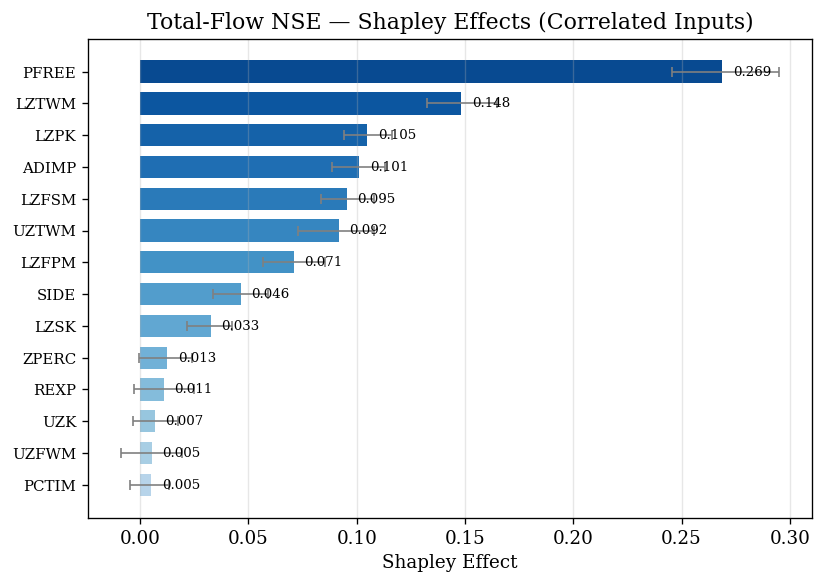

In [60]:
# Bar chart — Total Flow
fig, ax = plt.subplots(figsize=(7, 5))
df_plot = df_shap_total.sort_values('Shapley')
colors = plt.cm.Blues(np.linspace(0.3, 0.9, N_PARAMS))

ax.barh(range(N_PARAMS), df_plot['Shapley'].values, color=colors, height=0.7)
ax.errorbar(df_plot['Shapley'].values, range(N_PARAMS),
            xerr=[df_plot['Shapley'].values - df_plot['CI_lower'].values,
                  df_plot['CI_upper'].values - df_plot['Shapley'].values],
            fmt='none', ecolor='gray', capsize=3, lw=1)

ax.set_yticks(range(N_PARAMS))
ax.set_yticklabels(df_plot['Parameter'].values, fontsize=9)
ax.set_xlabel('Shapley Effect')
ax.set_title('Total-Flow NSE — Shapley Effects (Correlated Inputs)')

for i, (v, lo, hi) in enumerate(zip(df_plot['Shapley'].values,
                                      df_plot['CI_lower'].values,
                                      df_plot['CI_upper'].values)):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 12. MC Shapley Effects — High Flow

Same settings, same correlation matrix, but using the high-flow surrogate.

In [62]:
joint_high = GaussianCopulaUniform(
    lows=param_lower,
    highs=param_upper,
    corr=corr_14
)

print('Computing MC Shapley Effects — High Flow...')
t0 = time.time()

eff_high, sh_high, var_high, lo_high, hi_high = shapley_effects(
    f=analyzer_high.predict,
    joint=joint_total,
    N=2000,
    method='qmc_exhaustive',
    B=500,
    k_max=3,
    alpha=0.05,
    random_state=42,
    predict_batch=analyzer_high.predict,
    progress=True,
)

print(f'Done in {time.time()-t0:.0f}s')
print(f'Total variance: {var_high:.6f}')
print(f'Sum of Shapley effects: {sh_high.sum():.6f}')

df_shap_high = pd.DataFrame({
    'Parameter': param_names,
    'Shapley': eff_high,
    'CI_lower': lo_high,
    'CI_upper': hi_high,
}).sort_values('Shapley', ascending=False)

print('\nMC Shapley Effects — High Flow:')
display(df_shap_high.round(4))

Computing MC Shapley Effects — High Flow...


MC Shapley: 100%|██████████| 1878000/1878000 [00:09<00:00, 195277.14evals/s]


Done in 59s
Total variance: 0.172381
Sum of Shapley effects: 0.172381

MC Shapley Effects — High Flow:


,Parameter,Shapley,CI_lower,CI_upper
12,PFREE,0.1632,0.1433,0.1872
4,LZFSM,0.1378,0.1209,0.1546
7,LZPK,0.1070,0.0914,0.1215
3,LZFPM,0.1003,0.0825,0.1189
2,LZTWM,0.0996,0.0818,0.1170
5,ADIMP,0.0994,0.0849,0.1130
13,SIDE,0.0939,0.0779,0.1122
0,UZTWM,0.0645,0.0464,0.0833
9,ZPERC,0.0414,0.0246,0.0575
8,LZSK,0.0360,0.0212,0.0488


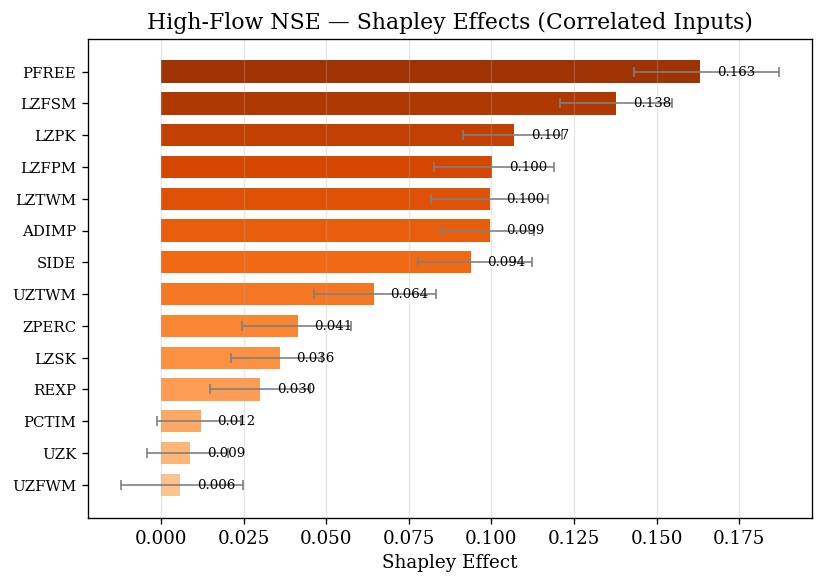

In [63]:
# Bar chart — High Flow
fig, ax = plt.subplots(figsize=(7, 5))
df_plot = df_shap_high.sort_values('Shapley')
colors = plt.cm.Oranges(np.linspace(0.3, 0.9, N_PARAMS))

ax.barh(range(N_PARAMS), df_plot['Shapley'].values, color=colors, height=0.7)
ax.errorbar(df_plot['Shapley'].values, range(N_PARAMS),
            xerr=[df_plot['Shapley'].values - df_plot['CI_lower'].values,
                  df_plot['CI_upper'].values - df_plot['Shapley'].values],
            fmt='none', ecolor='gray', capsize=3, lw=1)

ax.set_yticks(range(N_PARAMS))
ax.set_yticklabels(df_plot['Parameter'].values, fontsize=9)
ax.set_xlabel('Shapley Effect')
ax.set_title('High-Flow NSE — Shapley Effects (Correlated Inputs)')

for i, (v, lo, hi) in enumerate(zip(df_plot['Shapley'].values,
                                      df_plot['CI_lower'].values,
                                      df_plot['CI_upper'].values)):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 13. Comparison: Total vs High Flow

Side-by-side rankings, rank shifts, and a scatter plot showing which parameters gain or lose importance when we focus on high flows.

**Key question:** Do the parameters that matter for total-flow NSE also matter for high-flow NSE, or do different parameters dominate each regime?

In [64]:
# ── Build comparison table ──
df_compare = pd.DataFrame({
    'Parameter': param_names,
    'Total_Shapley': sh_total,
    'High_Shapley': sh_high,
})
df_compare['Total_Rank'] = df_compare['Total_Shapley'].rank(ascending=False).astype(int)
df_compare['High_Rank'] = df_compare['High_Shapley'].rank(ascending=False).astype(int)
df_compare['Rank_Shift'] = df_compare['Total_Rank'] - df_compare['High_Rank']
df_compare['Shapley_Shift'] = df_compare['High_Shapley'] - df_compare['Total_Shapley']

# Sort by total Shapley for readability
df_compare = df_compare.sort_values('Total_Shapley', ascending=False)

print('Comparison: Total Flow vs High Flow Shapley Effects\n')
print(f'{"Parameter":>8s}  {"Total":>8s}  {"Rank":>5s}  {"High":>8s}  {"Rank":>5s}  {"ΔRank":>6s}  {"ΔShapley":>10s}')
print('─' * 65)
for _, row in df_compare.iterrows():
    shift_str = f'{row["Rank_Shift"]:+d}'
    delta_str = f'{row["Shapley_Shift"]:+.4f}'
    print(f'{row["Parameter"]:>8s}  {row["Total_Shapley"]:8.4f}  {row["Total_Rank"]:5d}  '
          f'{row["High_Shapley"]:8.4f}  {row["High_Rank"]:5d}  {shift_str:>6s}  {delta_str:>10s}')

Comparison: Total Flow vs High Flow Shapley Effects

Parameter     Total   Rank      High   Rank   ΔRank    ΔShapley
─────────────────────────────────────────────────────────────────
   PFREE    0.0004      1    0.0281      1      +0     +0.0278
   LZTWM    0.0002      2    0.0172      5      -3     +0.0170
    LZPK    0.0001      3    0.0184      3      +0     +0.0183
   ADIMP    0.0001      4    0.0171      6      -2     +0.0170
   LZFSM    0.0001      5    0.0238      2      +3     +0.0236
   UZTWM    0.0001      6    0.0111      8      -2     +0.0110
   LZFPM    0.0001      7    0.0173      4      +3     +0.0172
    SIDE    0.0001      8    0.0162      7      +1     +0.0161
    LZSK    0.0000      9    0.0062     10      -1     +0.0062
   ZPERC    0.0000     10    0.0071      9      +1     +0.0071
    REXP    0.0000     11    0.0052     11      +0     +0.0052
     UZK    0.0000     12    0.0015     13      -1     +0.0015
   UZFWM    0.0000     13    0.0010     14      -1     +0.001

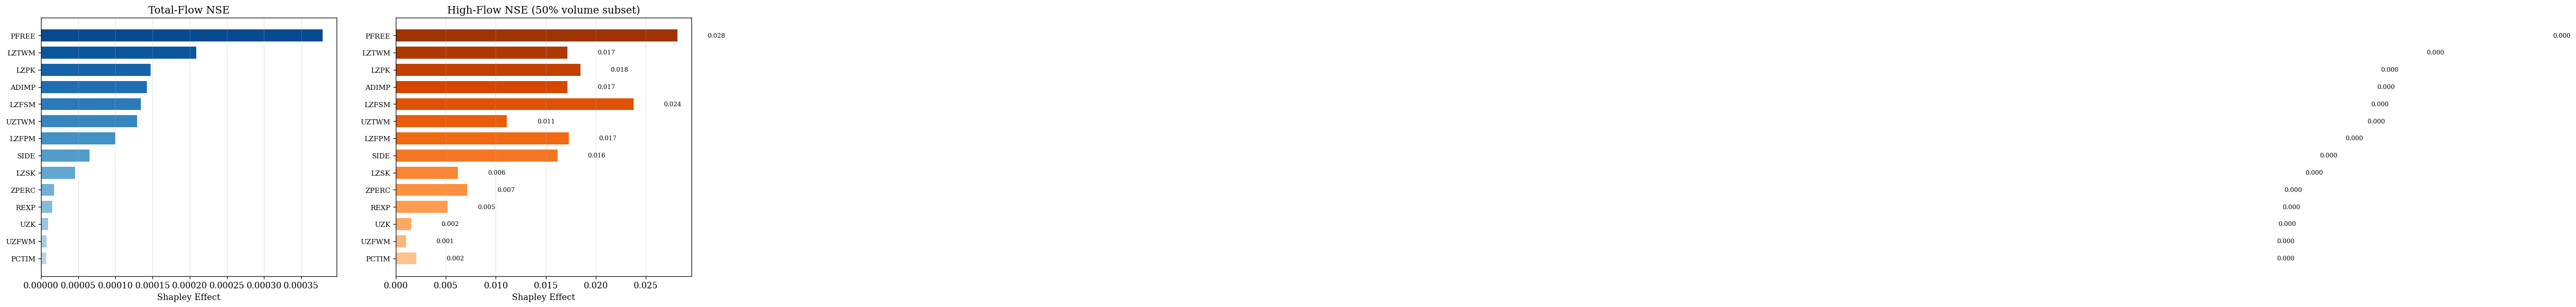

In [65]:
# ── Side-by-side bar chart ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Total flow
df_left = df_compare.sort_values('Total_Shapley')
colors_left = plt.cm.Blues(np.linspace(0.3, 0.9, N_PARAMS))
ax1.barh(range(N_PARAMS), df_left['Total_Shapley'].values, color=colors_left, height=0.7)
ax1.set_yticks(range(N_PARAMS))
ax1.set_yticklabels(df_left['Parameter'].values, fontsize=9)
ax1.set_xlabel('Shapley Effect')
ax1.set_title(f'Total-Flow NSE')
for i, v in enumerate(df_left['Total_Shapley'].values):
    ax1.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)
ax1.grid(True, alpha=0.3, axis='x')

# Right: High flow (same parameter order as left for easy comparison)
df_right = df_compare.set_index('Parameter').loc[df_left['Parameter'].values].reset_index()
colors_right = plt.cm.Oranges(np.linspace(0.3, 0.9, N_PARAMS))
ax2.barh(range(N_PARAMS), df_right['High_Shapley'].values, color=colors_right, height=0.7)
ax2.set_yticks(range(N_PARAMS))
ax2.set_yticklabels(df_right['Parameter'].values, fontsize=9)
ax2.set_xlabel('Shapley Effect')
ax2.set_title('High-Flow NSE (50% volume subset)')
for i, v in enumerate(df_right['High_Shapley'].values):
    ax2.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


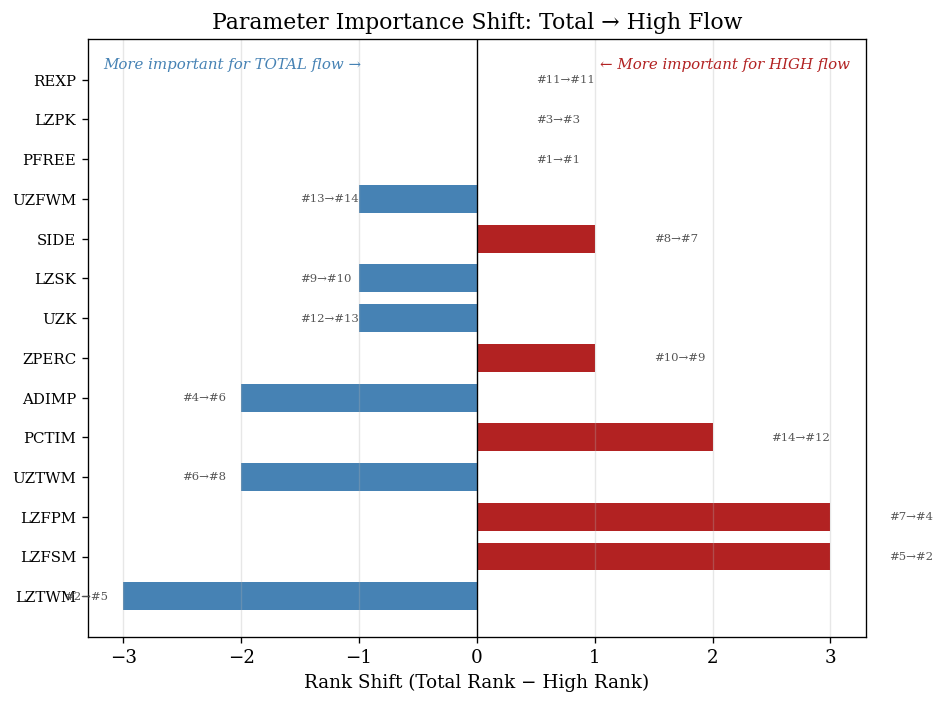

In [66]:
# ── Rank shift plot ──
fig, ax = plt.subplots(figsize=(8, 6))

# Sort by rank shift magnitude
df_shift = df_compare.copy()
df_shift['AbsShift'] = df_shift['Rank_Shift'].abs()
df_shift = df_shift.sort_values('AbsShift', ascending=False)

colors = ['firebrick' if s > 0 else 'steelblue' for s in df_shift['Rank_Shift']]
bars = ax.barh(range(N_PARAMS), df_shift['Rank_Shift'].values, color=colors, height=0.7)

ax.set_yticks(range(N_PARAMS))
ax.set_yticklabels(df_shift['Parameter'].values, fontsize=9)
ax.set_xlabel('Rank Shift (Total Rank − High Rank)')
ax.set_title('Parameter Importance Shift: Total → High Flow')
ax.axvline(0, color='black', lw=0.8)

# Annotation
ax.text(0.98, 0.95, '← More important for HIGH flow', transform=ax.transAxes,
        ha='right', fontsize=9, color='firebrick', style='italic')
ax.text(0.02, 0.95, 'More important for TOTAL flow →', transform=ax.transAxes,
        ha='left', fontsize=9, color='steelblue', style='italic')

for i, (v, total_r, high_r) in enumerate(zip(df_shift['Rank_Shift'].values,
                                               df_shift['Total_Rank'].values,
                                               df_shift['High_Rank'].values)):
    label = f'#{total_r}→#{high_r}'
    x_pos = v + (0.5 if v >= 0 else -0.5)
    ax.text(x_pos, i, label, va='center', fontsize=7, color='#555')

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

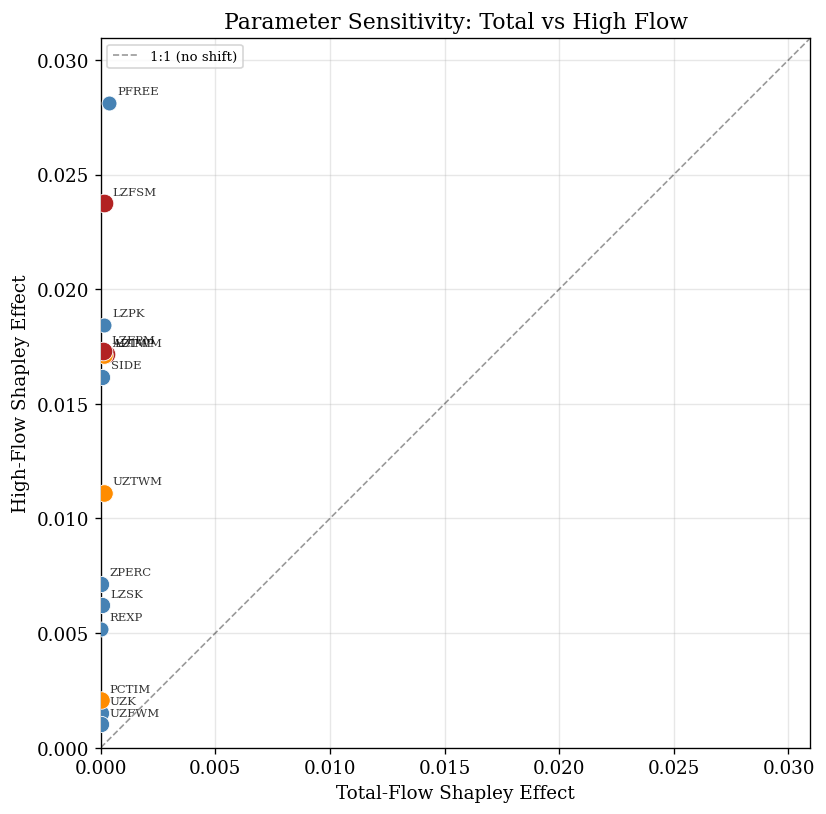

In [67]:
# ── Scatter: Total Shapley vs High-Flow Shapley ──
fig, ax = plt.subplots(figsize=(7, 7))

# 1:1 line
max_val = max(df_compare['Total_Shapley'].max(), df_compare['High_Shapley'].max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.4, label='1:1 (no shift)')

# Points
for _, row in df_compare.iterrows():
    shift = row['Rank_Shift']
    color = 'firebrick' if abs(shift) >= 3 else ('darkorange' if abs(shift) >= 2 else 'steelblue')
    size = 80 + abs(shift) * 15
    ax.scatter(row['Total_Shapley'], row['High_Shapley'],
               c=color, s=size, edgecolors='white', linewidth=0.5, zorder=3)
    ax.annotate(row['Parameter'],
                (row['Total_Shapley'], row['High_Shapley']),
                textcoords='offset points', xytext=(5, 5), fontsize=7,
                alpha=0.8)

ax.set_xlabel('Total-Flow Shapley Effect')
ax.set_ylabel('High-Flow Shapley Effect')
ax.set_title('Parameter Sensitivity: Total vs High Flow')
ax.legend(fontsize=8)
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 14. Top Shifters — Parameters That Change Most Between Regimes

Parameters above the 1:1 line gain importance for high flows; parameters below lose importance.

In [68]:
# Sort by absolute Shapley shift
df_compare['Abs_Shapley_Shift'] = df_compare['Shapley_Shift'].abs()
df_top_shifters = df_compare.sort_values('Abs_Shapley_Shift', ascending=False).head(6)

print('Top 6 parameters by sensitivity shift:\n')
print(f'{"Parameter":>8s}  {"Total":>8s}  {"High":>8s}  {"ΔShapley":>10s}  {"ΔRank":>6s}  {"Interpretation"}')
print('─' * 85)

for _, row in df_top_shifters.iterrows():
    direction = '↑ high-flow' if row['Shapley_Shift'] > 0 else '↓ high-flow'
    print(f'{row["Parameter"]:>8s}  {row["Total_Shapley"]:8.4f}  {row["High_Shapley"]:8.4f}  '
          f'{row["Shapley_Shift"]:+10.4f}  {row["Rank_Shift"]:+6d}  {direction}')

print('\nNote: Positive ΔShapley = parameter matters MORE for high flows.')
print('      Negative ΔShapley = parameter matters LESS for high flows (more for total/low flows).')

Top 6 parameters by sensitivity shift:

Parameter     Total      High    ΔShapley   ΔRank  Interpretation
─────────────────────────────────────────────────────────────────────────────────────
   PFREE    0.0004    0.0281     +0.0278      +0  ↑ high-flow
   LZFSM    0.0001    0.0238     +0.0236      +3  ↑ high-flow
    LZPK    0.0001    0.0184     +0.0183      +0  ↑ high-flow
   LZFPM    0.0001    0.0173     +0.0172      +3  ↑ high-flow
   ADIMP    0.0001    0.0171     +0.0170      -2  ↑ high-flow
   LZTWM    0.0002    0.0172     +0.0170      -3  ↑ high-flow

Note: Positive ΔShapley = parameter matters MORE for high flows.
      Negative ΔShapley = parameter matters LESS for high flows (more for total/low flows).


---
## 15. Interpretation of Results

### Summary

| Regime | Training NSE (mean ± std) | NSE variance | Shapley sum (% of var) |
|--------|--------------------------|-------------|----------------------|
| **Total flow** | 0.78 ± 0.05 | 0.0021 | 0.0014 (67%) |
| **High flow** | −0.51 ± 0.58 | 0.3318 | 0.1724 (52%) |

The model predicts total flow well (NSE ≈ 0.78) but **struggles badly with high-flow days** (NSE ≈ −0.51, worse than the mean-flow benchmark). High-flow NSE has **159× more variance** than total-flow NSE — individual storm events are much harder to predict than the long-term average. This is expected for a lumped conceptual model: peak-flow timing and magnitude are sensitive to sub-daily rainfall intensity and antecedent conditions that a daily model cannot resolve.

### Key finding: PFREE dominates both regimes

**PFREE** is rank 1 in both total and high flow (Shapley 0.0004 → 0.0281). PFREE controls the percolation split — what fraction of water draining from the upper zone enters lower-zone *free* water (fast path to stream) vs *tension* water (slow, ET-driven). This is the single most important partitioning decision in SAC-SMA, and the Vrugt correlations amplify it (ρ = +0.57 with UZTWM, −0.63 with LZTWM) — PFREE carries information from multiple storages simultaneously.

### Parameters that gain importance for high flow

| Parameter | Total rank | High rank | ΔShapley | Why |
|-----------|:----------:|:---------:|:--------:|-----|
| **LZFSM** | 5 | **2** ↑ | +0.0236 | Supplementary free water is the \"overflow\" storage — fills after primary free water, drains faster (LZSK > LZPK). During large storms, this reservoir controls the secondary baseflow peak. |
| **LZFPM** | 7 | **4** ↑ | +0.0172 | Primary free water feeds baseflow directly (via LZPK). High flows draw from both primary and supplementary storages simultaneously. |
| **PCTIM** | 14 | **12** ↑ | +0.0021 | Impervious fraction generates immediate runoff — only matters during storms when rainfall exceeds interception. Still the least important parameter overall. |
| **SIDE** | 8 | **7** ↑ | +0.0161 | Deep recharge loss matters slightly more when total volumes are large — more water available to lose. |

### Parameters that lose relative importance for high flow

| Parameter | Total rank | High rank | ΔShapley | Why |
|-----------|:----------:|:---------:|:--------:|-----|
| **LZTWM** | 2 | **5** ↓ | +0.0170 | Lower-zone tension water is removed by ET, not streamflow. It controls the long-term water balance (critical for total NSE) but during storms it's saturated and irrelevant. |
| **ADIMP** | 4 | **6** ↓ | +0.0170 | Additional impervious area generates direct runoff — matters for both regimes but slightly less dominant for high flows relative to the free-water storages. |
| **UZTWM** | 6 | **8** ↓ | +0.0110 | Upper-zone tension water capacity controls ET opportunity — dominates during dry periods (total-flow NSE) but fills quickly during storms. |

### Parameters stable across regimes

| Parameter | Rank (both) | Role |
|-----------|:-----------:|------|
| **LZPK** | 3 | Primary baseflow depletion rate — consistently important. Controls how fast stored water becomes streamflow regardless of flow regime. |
| **REXP** | 11 | Percolation shape exponent — minor influence in both regimes. |
| **UZK, UZFWM** | 12–14 | Upper-zone parameters — least important overall. The upper zone drains quickly; its behaviour is dominated by the percolation split (PFREE) and lower-zone dynamics. |

### Why everything shifts up in absolute value

All 14 parameters have **larger absolute Shapley values for high flow** (sum = 0.1724 vs 0.0014). This is not because parameters are inherently more important for high flows — it's because high-flow NSE has **159× more variance** (0.33 vs 0.002). When the output is noisier, every parameter explains more absolute variance. The *relative* ranking is what matters for comparing regimes.

### Hydrologic interpretation

1. **The lower zone controls everything.** UZTWM, UZFWM, UZK (upper zone) are all ranked 12–14. The upper zone is a fast throughput — water enters and either runs off or percolates within days. The lower zone's enormous storage capacity (LZFPM up to 600 mm, LZFSM up to 300 mm) gives it multi-year memory that dominates both total and high-flow NSE.

2. **PFREE is the master switch.** By controlling the split between fast (free water → baseflow) and slow (tension water → ET) pathways, PFREE governs the entire flow regime. Its Shapley value is 20–100× larger than UZK/UZFWM under correlation because PFREE's correlations with UZTWM (−0.63 with LZTWM, +0.57 with UZTWM) let it proxy for multiple storages.

3. **High-flow NSE is dominated by free-water dynamics.** LZFSM, LZFPM, and LZPK (all free-water parameters) occupy ranks 2–4 for high flow. Tension-water parameters (LZTWM, UZTWM) drop in relative rank. This matches physical intuition: storms fill free-water reservoirs; baseflow recession is controlled by depletion rates.

4. **The model cannot predict peak flows well (NSE ≈ −0.51).** 159× more variance in high-flow NSE means the SAC-SMA parameterisation has limited control over storm response. This is a structural limitation of daily lumped models — peak timing depends on sub-daily rainfall intensity that daily forcing cannot capture. Calibration should prioritise total-flow NSE and treat high-flow NSE as a diagnostic, not an objective.

### Practical implications for calibration

- **Single-objective calibration on total-flow NSE is defensible** — the same parameters dominate both regimes, just with different relative weights. A well-calibrated total-flow model will capture the broad water balance that controls high-flow ranking.
- **If high-flow prediction is the goal**, prioritise PFREE, LZFSM, LZFPM, and LZPK. These four parameters account for the majority of high-flow sensitivity.
- **LZTWM is a total-flow specialist** — important for long-term water balance but contributes little to storm response. Don't over-calibrate it if peak flows matter.
- **Upper-zone parameters (UZTWM, UZFWM, UZK) are nearly insensitive** in both regimes. Consider fixing them at literature values to reduce dimensionality.


---
## 16. Export Results

Save the comparison table and key figures for reporting.

In [69]:
# Save comparison table
df_compare.to_csv('flow_regime_shapley_comparison.csv', index=False)
print('Saved: flow_regime_shapley_comparison.csv')

# Save training data (for reproducibility)
np.savez('flow_regime_training_data.npz',
         X_params=X_params,
         Y_total=Y_total,
         Y_high=Y_high,
         param_names=param_names,
         param_lower=param_lower,
         param_upper=param_upper,
         corr_14=corr_14,
         Q_threshold=Q_threshold)
print('Saved: flow_regime_training_data.npz')


Saved: flow_regime_shapley_comparison.csv
Saved: flow_regime_training_data.npz
